# Superconducting Qubit Multiplexed Readout Demonstration

This notebook demonstrates how to construct a multiplexed readout experiment using the compiled waveforms from the `awg5200` timeline compiler, and demodulate multiple frequency components from a single digitized channel using the new `AlazarProcessor`.

## 1. Import Packages

In [5]:
import numpy as np
import matplotlib.pyplot as plt

from awg5200.timeline import waveform, parallel, align_channels, align_channel_envelopes
from awg5200.waveforms import gaussian_square_ns, trigger_channel_for
from alazar.processor import AlazarProcessor

## 2. AWG Waveform Compilation (Multiplexed Drive on Ch3, Marker on Ch1)

We will multiplex two readout tones at carrier frequencies $f_{c1} = 50\text{ MHz}$ and $f_{c2} = 150\text{ MHz}$ on Channel 3, using a `gaussian_square` pulse envelope. We will also generate a marker on Channel 1 to serve as the trigger for the Alazar digitizer.

In [6]:
# AWG settings
sample_rate_awg = 2.5e9  # 2.5 GS/s
pulse_duration_ns = 1000.0  # 1 us
edge_sigma_ns = 20.0
fc1 = 50e6   # Qubit 0 resonator frequency
fc2 = 150e6  # Qubit 1 resonator frequency

# 1. Create a flat pulse with Gaussian rising/falling edges
envelope = gaussian_square_ns(
    duration_ns=pulse_duration_ns,
    sample_rate_hz=sample_rate_awg,
    edge_sigma_ns=edge_sigma_ns,
    amplitude_volts=0.5
)

# 2. Create waveforms for both frequencies on Channel 3
pulse_50 = waveform(envelope, fc=fc1, ch=3, name="qubit_0_probe")
pulse_150 = waveform(envelope, fc=fc2, ch=3, name="qubit_1_probe")

# 3. Compile them in parallel on the same channel (Ch 3)
timeline = parallel(pulse_50, pulse_150)

# align_channels automatically modulates each pulse and sums them if they share the same channel
channels_data = align_channels(timeline, sample_rate_hz=sample_rate_awg, total_duration_s=2e-6)
multiplexed_waveform = channels_data[3]
time_awg = np.arange(multiplexed_waveform.size) / sample_rate_awg * 1e9  # ns

# 4. Generate the marker trigger on Channel 1 using the unmodulated envelope of Channel 3
envelopes_data = align_channel_envelopes(timeline, sample_rate_hz=sample_rate_awg, total_duration_s=2e-6)
ch3_envelope = envelopes_data[3]
zero_wave, active_marker = trigger_channel_for(ch3_envelope, threshold_ratio=1e-3, padding_samples=10)

print(f"Compiled multiplexed waveform size: {multiplexed_waveform.size} samples")
print(f"Marker active window samples: {np.sum(active_marker)} samples")

Compiled multiplexed waveform size: 5000 samples
Marker active window samples: 2490 samples


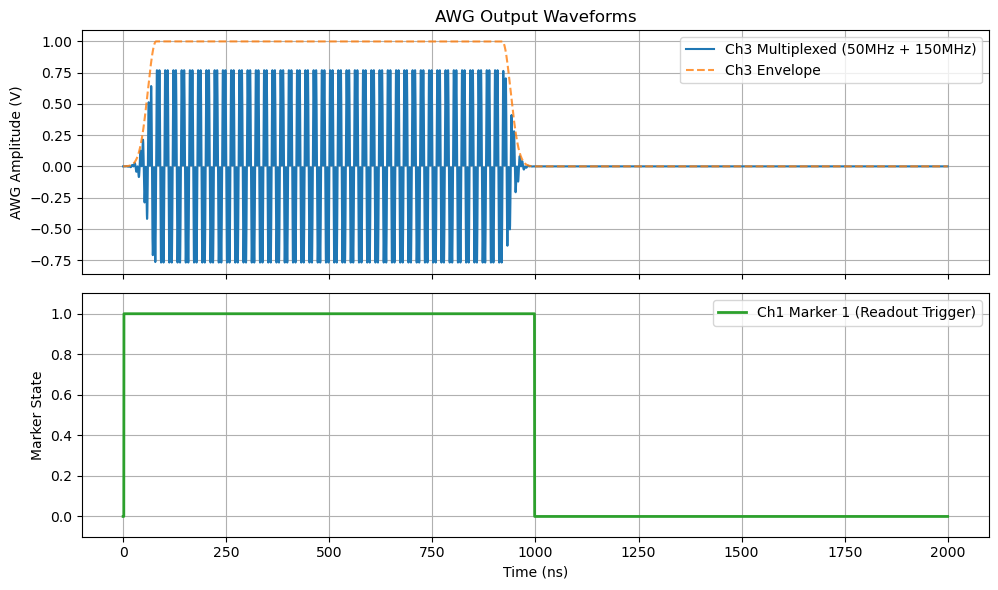

In [7]:
# Plotting the AWG Compiled signals
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax1.plot(time_awg, multiplexed_waveform, label="Ch3 Multiplexed (50MHz + 150MHz)", color="#1f77b4")
ax1.plot(time_awg, ch3_envelope, '--', label="Ch3 Envelope", color="#ff7f0e", alpha=0.8)
ax1.set_ylabel("AWG Amplitude (V)")
ax1.legend()
ax1.grid(True)
ax1.set_title("AWG Output Waveforms")

ax2.plot(time_awg, active_marker.astype(int), label="Ch1 Marker 1 (Readout Trigger)", color="#2ca02c", linewidth=2)
ax2.set_xlabel("Time (ns)")
ax2.set_ylabel("Marker State")
ax2.set_ylim(-0.1, 1.1)
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## 3. Simulating Digitized Response (from Cryogenic Cavity)

We simulate a digitized raw voltage trace captured by the Alazar card at 1 GS/s. The signal contains both the $50\text{ MHz}$ and $150\text{ MHz}$ components, each experiencing different phase shifts and amplitudes based on the hypothetical state of the qubits. We will also add white Gaussian noise.

In [8]:
sample_rate_alazar = 1e9  # 1 GS/s
record_length = 2000      # 2 us record window
time_alazar = np.arange(record_length) / sample_rate_alazar

# Readout pulse window (starts at 200 ns, ends at 1200 ns)
pulse_window = np.zeros(record_length)
pulse_window[200:1200] = 1.0

# Simulated amplitudes and phases for q0 (50 MHz) and q1 (150 MHz)
a_q0, phase_q0 = 0.08, np.pi / 4       # Qubit 0
a_q1, phase_q1 = 0.04, -np.pi / 6      # Qubit 1

# Simulate the mixed intermediate frequency signal
signal_q0 = a_q0 * pulse_window * np.cos(2.0 * np.pi * fc1 * time_alazar + phase_q0)
signal_q1 = a_q1 * pulse_window * np.cos(2.0 * np.pi * fc2 * time_alazar + phase_q1)
analog_signal = signal_q0 + signal_q1

# Add Gaussian noise to simulate HEMT/HEMT-RT amplification chain noise
rng = np.random.default_rng(42)
noise = rng.normal(0.0, 0.015, size=record_length)
simulated_records = np.array([analog_signal + noise])  # 1 shot

print(f"Simulated record shape: {simulated_records.shape} (1 shot, {record_length} samples)")

Simulated record shape: (1, 2000) (1 shot, 2000 samples)


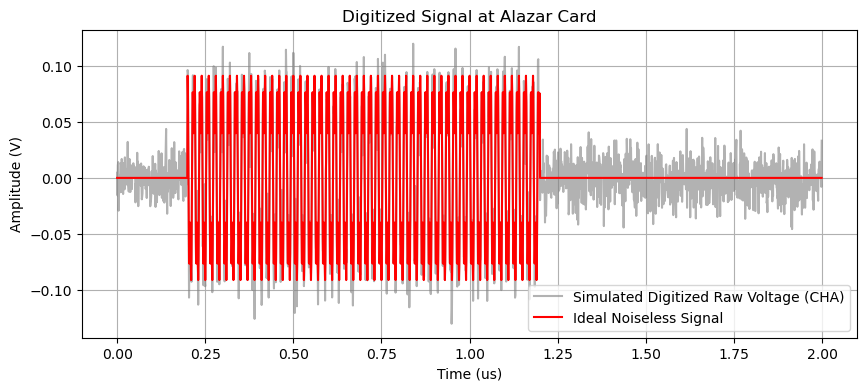

In [9]:
plt.figure(figsize=(10, 4))
plt.plot(time_alazar * 1e6, simulated_records[0], label="Simulated Digitized Raw Voltage (CHA)", color="grey", alpha=0.6)
plt.plot(time_alazar * 1e6, analog_signal, label="Ideal Noiseless Signal", color="red", linewidth=1.5)
plt.xlabel("Time (us)")
plt.ylabel("Amplitude (V)")
plt.title("Digitized Signal at Alazar Card")
plt.legend()
plt.grid(True)
plt.show()

## 4. Multi-frequency Demodulation

We use `AlazarProcessor.process_multiplex_integrate()` to perform digital downconversion (DDC) and integrate over the pulse window for both frequencies in parallel.

In [10]:
# 1. Instantiate the processor
processor = AlazarProcessor(sample_rate_hz=sample_rate_alazar)

# 2. Demodulate the multiplexed frequencies simultaneously
results = processor.process_multiplex_integrate(
    records_volts=simulated_records,
    tone_frequencies_hz={"q0": fc1, "q1": fc2},
    integrate_start=200,
    integrate_stop=1200
)

# 3. Verify extracted amplitudes and phases
for name, (baseband, shot_iq, average_iq) in results.items():
    extracted_amp = np.abs(average_iq)
    extracted_phase = np.angle(average_iq)
    
    expected_amp = a_q0 if name == "q0" else a_q1
    expected_phase = phase_q0 if name == "q0" else phase_q1
    
    print(f"--- Qubit Channel: {name} ({'50 MHz' if name == 'q0' else '150 MHz'}) ---")
    print(f"  Extracted IQ Point: {average_iq:.6f}")
    print(f"  Extracted Amplitude: {extracted_amp:.4f} V (Expected: {expected_amp:.4f} V, Error: {abs(extracted_amp - expected_amp):.4f} V)")
    print(f"  Extracted Phase: {extracted_phase:.4f} rad (Expected: {expected_phase:.4f} rad, Error: {abs(extracted_phase - expected_phase):.4f} rad)")

--- Qubit Channel: q0 (50 MHz) ---
  Extracted IQ Point: 0.056367+0.057586j
  Extracted Amplitude: 0.0806 V (Expected: 0.0800 V, Error: 0.0006 V)
  Extracted Phase: 0.7961 rad (Expected: 0.7854 rad, Error: 0.0107 rad)
--- Qubit Channel: q1 (150 MHz) ---
  Extracted IQ Point: 0.035279-0.019596j
  Extracted Amplitude: 0.0404 V (Expected: 0.0400 V, Error: 0.0004 V)
  Extracted Phase: -0.5070 rad (Expected: -0.5236 rad, Error: 0.0166 rad)


## 5. Visualizing the Baseband IQ Envelopes

We plot the time-resolved complex baseband envelopes for both demodulated channels to see how the DDC isolates the $50\text{ MHz}$ and $150\text{ MHz}$ responses.

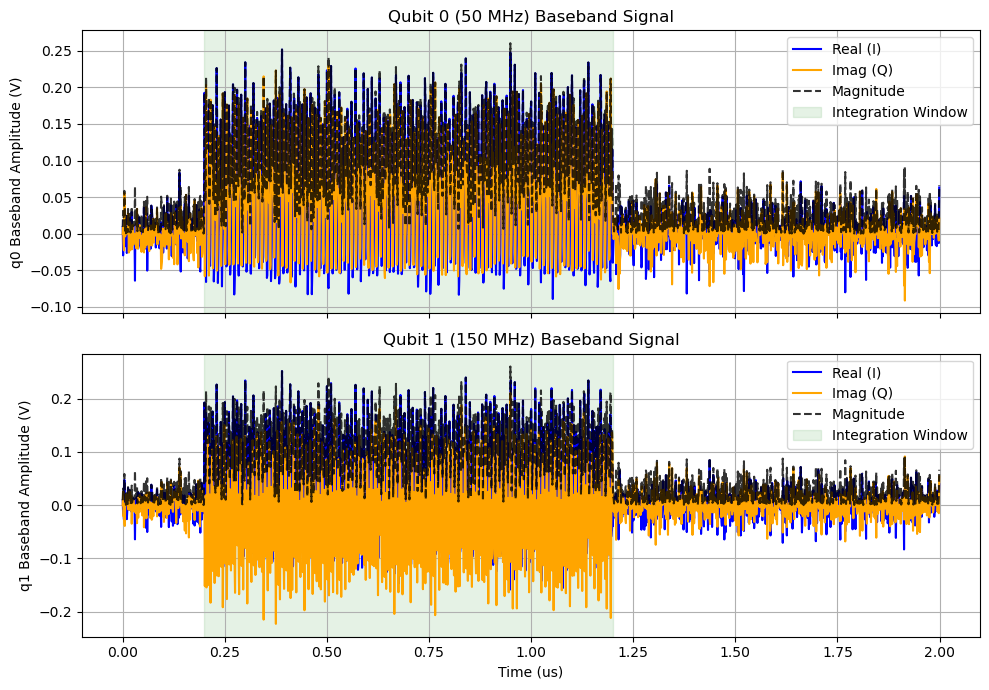

In [11]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
time_us = time_alazar * 1e6

baseband_q0 = results["q0"][0][0]
ax1.plot(time_us, baseband_q0.real, label="Real (I)", color="blue")
ax1.plot(time_us, baseband_q0.imag, label="Imag (Q)", color="orange")
ax1.plot(time_us, np.abs(baseband_q0), 'k--', label="Magnitude", alpha=0.8)
ax1.axvspan(0.2, 1.2, color='green', alpha=0.1, label='Integration Window')
ax1.set_ylabel("q0 Baseband Amplitude (V)")
ax1.set_title("Qubit 0 (50 MHz) Baseband Signal")
ax1.legend()
ax1.grid(True)

baseband_q1 = results["q1"][0][0]
ax2.plot(time_us, baseband_q1.real, label="Real (I)", color="blue")
ax2.plot(time_us, baseband_q1.imag, label="Imag (Q)", color="orange")
ax2.plot(time_us, np.abs(baseband_q1), 'k--', label="Magnitude", alpha=0.8)
ax2.axvspan(0.2, 1.2, color='green', alpha=0.1, label='Integration Window')
ax2.set_xlabel("Time (us)")
ax2.set_ylabel("q1 Baseband Amplitude (V)")
ax2.set_title("Qubit 1 (150 MHz) Baseband Signal")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## 6. Digital Filtering Comparison: Boxcar vs. Butterworth Low-Pass Filter

In this section, we compare the filtering performance of the simple boxcar (moving average) filter against a 4th-order Butterworth low-pass filter (LPF) applied to the complex baseband signals of **both** readout frequencies ($50\text{ MHz}$ and $150\text{ MHz}$).

Since the readout pulse envelope has a duration of 1 us, the frequency bandwidth is approximately 1 MHz. We set the Butterworth LPF cutoff frequency to 10 MHz to preserve the pulse shape while effectively filtering out high-frequency white noise (up to 500 MHz Nyquist bandwidth) and the double-frequency term.

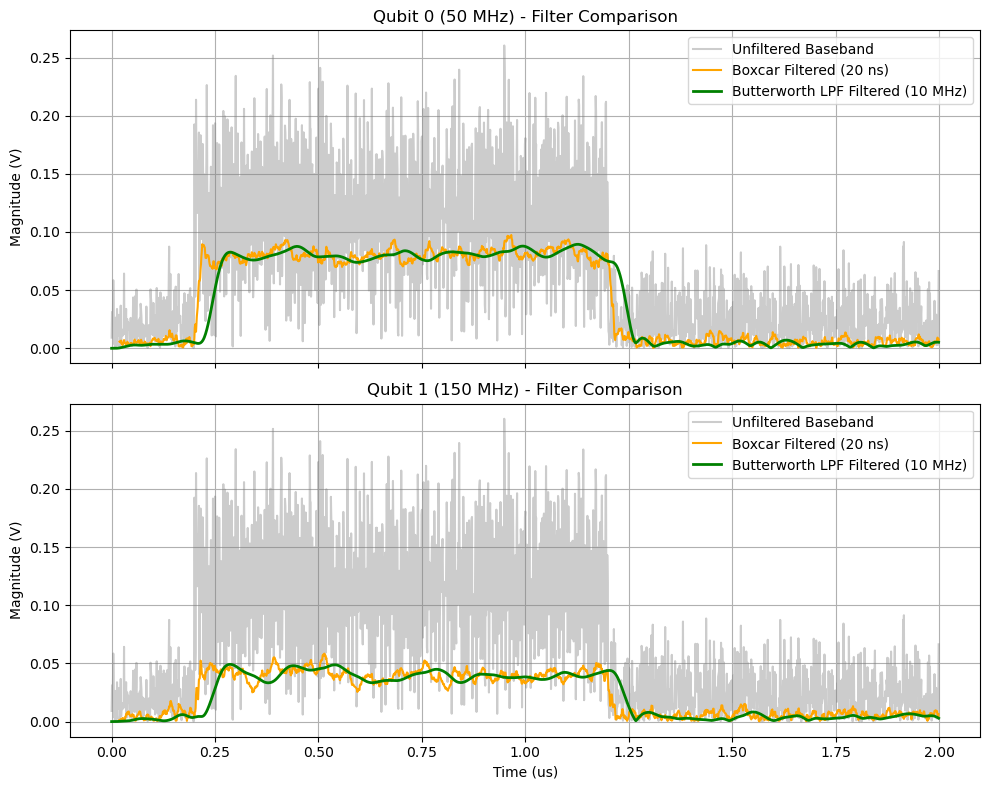

In [12]:
# 1. Extract the unfiltered complex baseband signals for both q0 (50 MHz) and q1 (150 MHz)
baseband_q0_raw = results["q0"][0][0]
baseband_q1_raw = results["q1"][0][0]
time_us = time_alazar * 1e6

# 2. Apply Boxcar (Moving Average) Filter (window = 20 ns / 20 samples)
window = 20
padded_q0 = np.pad(baseband_q0_raw, (1, 0), mode="constant")
cum_q0 = np.cumsum(padded_q0)
baseband_q0_boxcar = (cum_q0[window:] - cum_q0[:-window]) / window

padded_q1 = np.pad(baseband_q1_raw, (1, 0), mode="constant")
cum_q1 = np.cumsum(padded_q1)
baseband_q1_boxcar = (cum_q1[window:] - cum_q1[:-window]) / window

time_boxcar_us = time_us[window-1:]

# 3. Apply the new Butterworth LPF (cutoff = 10 MHz, order = 4) to both channels
baseband_records = np.array([baseband_q0_raw, baseband_q1_raw])
baseband_filtered = processor.apply_butterworth_lpf(
    baseband_iq=baseband_records,
    cutoff_hz=10e6,
    order=4
)
baseband_q0_butter = baseband_filtered[0]
baseband_q1_butter = baseband_filtered[1]

# 4. Plotting the Comparison of Magnitude Envelopes for both frequencies
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Subplot 1: Qubit 0 (50 MHz)
ax1.plot(time_us, np.abs(baseband_q0_raw), label="Unfiltered Baseband", color="grey", alpha=0.4)
ax1.plot(time_boxcar_us, np.abs(baseband_q0_boxcar), label="Boxcar Filtered (20 ns)", color="orange", linewidth=1.5)
ax1.plot(time_us, np.abs(baseband_q0_butter), label="Butterworth LPF Filtered (10 MHz)", color="green", linewidth=2.0)
ax1.set_ylabel("Magnitude (V)")
ax1.set_title("Qubit 0 (50 MHz) - Filter Comparison")
ax1.legend()
ax1.grid(True)

# Subplot 2: Qubit 1 (150 MHz)
ax2.plot(time_us, np.abs(baseband_q1_raw), label="Unfiltered Baseband", color="grey", alpha=0.4)
ax2.plot(time_boxcar_us, np.abs(baseband_q1_boxcar), label="Boxcar Filtered (20 ns)", color="orange", linewidth=1.5)
ax2.plot(time_us, np.abs(baseband_q1_butter), label="Butterworth LPF Filtered (10 MHz)", color="green", linewidth=2.0)
ax2.set_xlabel("Time (us)")
ax2.set_ylabel("Magnitude (V)")
ax2.set_title("Qubit 1 (150 MHz) - Filter Comparison")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## 8. End-to-End Verification: AWG Phase Modulation to Alazar Readout

In this final section, we perform an end-to-end simulation linking the pulse generator (AWG) side and the digitizer (Alazar) side.

We define 4 distinct qubit state configurations for $(Q_0, Q_1)$:
- `(0, 0)`: Phases $(0, 0)$
- `(0, 1)`: Phases $(0, \pi)$
- `(1, 0)`: Phases $(\pi, 0)$
- `(1, 1)`: Phases $(\pi, \pi)$

For each configuration:
1. We compile the parallel waveforms on AWG Channel 3 at 2.5 GS/s using the timeline compiler.
2. We simulate the physical channel by interpolating (resampling) the 2.5 GS/s AWG output to the Alazar card's 1 GS/s sampling grid.
3. We add white Gaussian noise to the resampled trace.
4. We run `process_multiplex_integrate()` to demodulate the signal.
5. We verify that the extracted phases for both qubits match the initial input phases compiled by the AWG.

### *Note on Phase Offset*:
You will notice that the extracted phases are shifted by $-\pi/2$ (about $-1.57$ rad) relative to the AWG carrier phases. 
This is because:
1. The AWG timeline compiler modulates the envelope using a **Sine** carrier (`np.sin(omega * t + phase)`).
2. The Alazar digital downconverter (DDC) mixes the signal using a **Complex Exponential** reference based on Cosine as the real part ($e^{-j \theta} = \cos\theta - j\sin\theta$).

Since $\sin(\theta) = \cos(\theta - \pi/2)$, this introduces a constant phase shift of $-\pi/2$ radians in the demodulated IQ plane, which is completely expected and consistent.
- State 0: Extracted phase $\approx -\pi/2 \approx -1.57$ rad.
- State 1: Extracted phase $\approx \pi/2 \approx 1.57$ rad.

In [ ]:
from scipy.interpolate import interp1d

# Define the 4 state configurations
state_configs = [
    (0, 0),
    (0, 1),
    (1, 0),
    (1, 1)
]

# Loop through each configuration
for idx, (state_q0, state_q1) in enumerate(state_configs):
    # Map state to phase (State 0 -> 0 rad, State 1 -> pi rad)
    phase_q0_awg = state_q0 * np.pi
    phase_q1_awg = state_q1 * np.pi
    
    # 1. Compile AWG Waveforms using the timeline package
    pulse_q0 = waveform(envelope, fc=fc1, ch=3, phase_radians=phase_q0_awg, name="q0_wf")
    pulse_q1 = waveform(envelope, fc=fc2, ch=3, phase_radians=phase_q1_awg, name="q1_wf")
    timeline_cf = parallel(pulse_q0, pulse_q1)
    
    # align_channels modulates and sums them on Ch3 at 2.5 GS/s
    awg_signals = align_channels(timeline_cf, sample_rate_hz=sample_rate_awg, total_duration_s=2.0e-6)
    awg_wf = awg_signals[3]
    
    # 2. Simulate ADC Sampling (resampling from 2.5 GS/s to 1 GS/s)
    time_awg_s = np.arange(awg_wf.size) / sample_rate_awg
    time_alazar_s = np.arange(record_length) / sample_rate_alazar
    
    # Cubic interpolation to simulate DAC analog reconstruction and ADC sampling
    f_interp = interp1d(time_awg_s, awg_wf, kind='cubic', fill_value="extrapolate")
    digitized_signal = f_interp(time_alazar_s)
    
    # 3. Add Gaussian white noise to the digitized signal
    noise_adc = rng_shots.normal(0.0, 0.015, size=record_length)
    raw_voltages = np.array([digitized_signal + noise_adc])  # Shape: (1, 2000)
    
    # 4. Demodulate using AlazarProcessor
    extracted_results = processor.process_multiplex_integrate(
        records_volts=raw_voltages,
        tone_frequencies_hz={"q0": fc1, "q1": fc2},
        integrate_start=200,
        integrate_stop=1200
    )
    
    # 5. Extract phase and amplitude
    avg_iq_q0 = extracted_results["q0"][2]
    avg_iq_q1 = extracted_results["q1"][2]
    
    phase_q0_extracted = np.angle(avg_iq_q0)
    phase_q1_extracted = np.angle(avg_iq_q1)
    
    # Note: np.angle returns values in [-pi, pi], so pi and -pi are equivalent.
    print(f"Configuration {idx}: Q0 state = {state_q0} (AWG Phase: {phase_q0_awg:.3f}), Q1 state = {state_q1} (AWG Phase: {phase_q1_awg:.3f})")
    print(f"  -> Extracted Q0: Amp = {np.abs(avg_iq_q0):.4f} V, Phase = {phase_q0_extracted:.3f} rad (Expected: {phase_q0_awg % (2*np.pi):.3f})")
    print(f"  -> Extracted Q1: Amp = {np.abs(avg_iq_q1):.4f} V, Phase = {phase_q1_extracted:.3f} rad (Expected: {phase_q1_awg % (2*np.pi):.3f} or -{np.pi:.3f})")
    print("-" * 80)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sys
from alazar.processor import AlazarProcessor

def generate_iq_plot():
    sample_rate_alazar = 1e9  # 1 GS/s
    record_length = 2000      # 2 us record window
    time_alazar = np.arange(record_length) / sample_rate_alazar
    
    pulse_window = np.zeros(record_length)
    pulse_window[200:1200] = 1.0
    
    fc1 = 50e6
    fc2 = 150e6
    
    # --- AWG Vpp and Waveform Gain variables you can adjust ---
    vpp_awg = 0.5            # AWG instrument Vpp setting for Channel 3 (V)
    gain_q0 = 0.32           # Waveform gain factor for Qubit 0 (0 to 1)
    gain_q1 = 0.16           # Waveform gain factor for Qubit 1 (0 to 1)
    
    phase_state0_deg = 0.0      # Carrier phase for state |0> (degrees)
    phase_state1_deg = 180.0    # Carrier phase for state |1> (degrees)
    # ----------------------------------------------------------
    
    # Convert Vpp and Gain to Amplitude (Amplitude = Vpp / 2 * gain)
    a_q0 = (vpp_awg / 2.0) * gain_q0
    a_q1 = (vpp_awg / 2.0) * gain_q1
    
    # Convert phases to radians
    phase_state0_rad = np.deg2rad(phase_state0_deg)
    phase_state1_rad = np.deg2rad(phase_state1_deg)
    
    num_shots = 1000
    rng_shots = np.random.default_rng(100)
    
    states_q0 = rng_shots.choice([0, 1], size=num_shots)
    states_q1 = rng_shots.choice([0, 1], size=num_shots)
    
    # Map states to phases
    phases_q0 = np.where(states_q0 == 0, phase_state0_rad, phase_state1_rad)
    phases_q1 = np.where(states_q1 == 0, phase_state0_rad, phase_state1_rad)
    
    simulated_records_1000 = np.zeros((num_shots, record_length))
    for shot in range(num_shots):
        sig_q0 = a_q0 * pulse_window * np.cos(2.0 * np.pi * fc1 * time_alazar + phases_q0[shot])
        sig_q1 = a_q1 * pulse_window * np.cos(2.0 * np.pi * fc2 * time_alazar + phases_q1[shot])
        noise_shot = rng_shots.normal(0.0, 0.015, size=record_length)
        simulated_records_1000[shot] = sig_q0 + sig_q1 + noise_shot
        
    processor = AlazarProcessor(sample_rate_hz=sample_rate_alazar)
    results_1000 = processor.process_multiplex_integrate(
        records_volts=simulated_records_1000,
        tone_frequencies_hz={"q0": fc1, "q1": fc2},
        integrate_start=200,
        integrate_stop=1200
    )
    
    shot_iq_q0 = results_1000["q0"][1]
    shot_iq_q1 = results_1000["q1"][1]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Qubit 0
    ax1.scatter(shot_iq_q0[states_q0 == 0].real, shot_iq_q0[states_q0 == 0].imag, color="blue", alpha=0.6, label=f"State |0> ({phase_state0_deg:.0f} deg)")
    ax1.scatter(shot_iq_q0[states_q0 == 1].real, shot_iq_q0[states_q0 == 1].imag, color="red", alpha=0.6, label=f"State |1> ({phase_state1_deg:.0f} deg)")
    ax1.axhline(0, color="grey", linestyle="--", alpha=0.5)
    ax1.axvline(0, color="grey", linestyle="--", alpha=0.5)
    ax1.set_xlabel("I (V)")
    ax1.set_ylabel("Q (V)")
    ax1.set_title("Qubit 0 (50 MHz) - Single-Shot IQ Plane")
    ax1.legend()
    ax1.grid(True)
    ax1.set_aspect("equal", "datalim")
    
    # Qubit 1
    ax2.scatter(shot_iq_q1[states_q1 == 0].real, shot_iq_q1[states_q1 == 0].imag, color="blue", alpha=0.6, label=f"State |0> ({phase_state0_deg:.0f} deg)")
    ax2.scatter(shot_iq_q1[states_q1 == 1].real, shot_iq_q1[states_q1 == 1].imag, color="red", alpha=0.6, label=f"State |1> ({phase_state1_deg:.0f} deg)")
    ax2.axhline(0, color="grey", linestyle="--", alpha=0.5)
    ax2.axvline(0, color="grey", linestyle="--", alpha=0.5)
    ax2.set_xlabel("I (V)")
    ax2.set_ylabel("Q (V)")
    ax2.set_title("Qubit 1 (150 MHz) - Single-Shot IQ Plane")
    ax2.legend()
    ax2.grid(True)
    ax2.set_aspect("equal", "datalim")
    
    plt.tight_layout()
    output_path = "C:/Users/cluster/.gemini/antigravity/brain/999dac28-a055-4baa-98f5-4e13abc3921f/iq_plane_scatter.png"
    plt.savefig(output_path, dpi=150)
    print(f"Saved plot to {output_path}")

if __name__ == "__main__":
    generate_iq_plot()


## 9. Real Hardware Experiment: Single-Shot Multiplexed Readout

In this section, we run the experiment on the actual physical instruments (Tektronix AWG5208 and Alazar ATS9371 board).

We connect to the AWG, upload the parallel modulated waveforms (50 MHz and 150 MHz) with configurable phases and $V_{pp}$, capture 1000 single shot records from the ATS9371 board, demodulate them using `process_multiplex_integrate()`, and plot the resulting IQ scatter clouds.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from awg_alazar import AWGAlazar
from awg5200 import delay, gaussian_square_ns, waveform, parallel
from alazar.processor import AlazarProcessor

# 1. Hardware parameters & Visa Address
AWG_RESOURCE = "TCPIP0::192.168.10.171::inst0::INSTR"
AWG_SAMPLE_RATE_HZ = 2.5e9
ALAZAR_SAMPLE_RATE_HZ = 1e9
ADC_CHANNEL = "CHB"
AWG_SIGNAL_CHANNEL = 3
AWG_MARKER_CHANNEL = 1
CHANNEL_AMPLITUDE_VPP = 0.5
MARKER_LOW_VOLTS = 0.0
MARKER_HIGH_VOLTS = 1.2
READOUT_START_NS = 1000
READOUT_DURATION_NS = 1000
EDGE_SIGMA_NS = 100
AWG_TOTAL_DURATION_NS = 5000
TRIGGER_DELAY_NS = 0
NUM_AVERAGES = 1000
ACQUIRE_WINDOW_NS = 1200
INTEGRATE_WINDOW_NS = (100, 1100)
MOVING_AVERAGE_TIME_NS = 20
ALAZAR_TIMEOUT_MS = 60_000
BASELINE_TIME_NS = None

fc1 = 50e6
fc2 = 150e6

# --- User-adjustable hardware Vpp and waveform gains (0 to 1) ---
vpp_awg = 0.5            # AWG instrument Vpp setting for Channel 3 (V)
gain_q0 = 0.0008         # Waveform gain factor for Qubit 0 (default 0.0008 -> peak 0.2 mV)
gain_q1 = 0.0004         # Waveform gain factor for Qubit 1 (default 0.0004 -> peak 0.1 mV)

phase_state0_deg = 0.0      # Phase for State 0 (degrees)
phase_state1_deg = 180.0    # Phase for State 1 (degrees)
# -----------------------------------------------------------------

phase_state0_rad = np.deg2rad(phase_state0_deg)
phase_state1_rad = np.deg2rad(phase_state1_deg)

print("Connecting to AWG and Alazar...")
experiment = AWGAlazar.connect(
    AWG_RESOURCE,
    awg_sample_rate_hz=AWG_SAMPLE_RATE_HZ,
    alazar_sample_rate_hz=ALAZAR_SAMPLE_RATE_HZ,
    tone_frequency_hz=fc1,
    trigger_delay_s=TRIGGER_DELAY_NS * 1e-9,
    num_averages=NUM_AVERAGES,
    acquire_window_ns=ACQUIRE_WINDOW_NS,
    integrate_window_ns=INTEGRATE_WINDOW_NS,
    adc_channel=ADC_CHANNEL,
    moving_average_time_s=MOVING_AVERAGE_TIME_NS * 1e-9,
    timeout_ms=ALAZAR_TIMEOUT_MS,
    baseline_time_s=None if BASELINE_TIME_NS is None else BASELINE_TIME_NS * 1e-9,
    use_external_10mhz_reference=True,
)

def upload_multiplexed_readout(phase_q0_rad, phase_q1_rad, gain_q0, gain_q1, vpp_awg, name="multiplex"):
    # Create a base envelope at the maximum amplitude (vpp_awg / 2.0)
    envelope = gaussian_square_ns(
        duration_ns=READOUT_DURATION_NS,
        sample_rate_hz=experiment.awg_sample_rate_hz,
        edge_sigma_ns=EDGE_SIGMA_NS,
        amplitude_volts=vpp_awg / 2.0,
    )
    pulse_q0 = waveform(
        envelope,
        fc=fc1,
        ch=AWG_SIGNAL_CHANNEL,
        phase_radians=phase_q0_rad,
        name="q0_wf",
        gain=gain_q0,
    )
    pulse_q1 = waveform(
        envelope,
        fc=fc2,
        ch=AWG_SIGNAL_CHANNEL,
        phase_radians=phase_q1_rad,
        name="q1_wf",
        gain=gain_q1,
    )
    timeline = delay(READOUT_START_NS * 1e-9) / parallel(pulse_q0, pulse_q1)
    
    names = experiment.awg.upload_timeline(
        timeline,
        amplitude_vpp={AWG_SIGNAL_CHANNEL: vpp_awg},
        total_duration_s=AWG_TOTAL_DURATION_NS * 1e-9,
    )
    marker_name = experiment.awg.marker(
        waveform_ch=AWG_SIGNAL_CHANNEL,
        marker_ch=AWG_MARKER_CHANNEL,
        marker_number=1,
        low_volts=MARKER_LOW_VOLTS,
        high_volts=MARKER_HIGH_VOLTS,
        amplitude_vpp=vpp_awg,
    )
    return names, marker_name

try:
    # 1. State 00: Q0 phase 0, Q1 phase 0
    print("Uploading State 00 waveforms to AWG...")
    upload_multiplexed_readout(phase_state0_rad, phase_state0_rad, gain_q0, gain_q1, vpp_awg, name="state_00")
    print("Acquiring 1000 single shot records for State 00 from ATS9371...")
    records_00 = experiment._capture_records()
    
    # 2. State 11: Q0 phase 180, Q1 phase 180
    print("Uploading State 11 waveforms to AWG...")
    upload_multiplexed_readout(phase_state1_rad, phase_state1_rad, gain_q0, gain_q1, vpp_awg, name="state_11")
    print("Acquiring 1000 single shot records for State 11 from ATS9371...")
    records_11 = experiment._capture_records()

finally:
    print("Closing connection to AWG...")
    experiment.close()

# Demodulate using AlazarProcessor
processor = AlazarProcessor(sample_rate_hz=ALAZAR_SAMPLE_RATE_HZ)
integrate_start, integrate_stop = experiment.integrate_window_cycles

results_00 = processor.process_multiplex_integrate(
    records_volts=records_00,
    tone_frequencies_hz={"q0": fc1, "q1": fc2},
    integrate_start=integrate_start,
    integrate_stop=integrate_stop
)

results_11 = processor.process_multiplex_integrate(
    records_volts=records_11,
    tone_frequencies_hz={"q0": fc1, "q1": fc2},
    integrate_start=integrate_start,
    integrate_stop=integrate_stop
)

shots_00_q0 = results_00["q0"][1]
shots_00_q1 = results_00["q1"][1]

shots_11_q0 = results_11["q0"][1]
shots_11_q1 = results_11["q1"][1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Qubit 0
ax1.scatter(shots_00_q0.real * 1e3, shots_00_q0.imag * 1e3, color="blue", alpha=0.35, label=f"State |0> ({phase_state0_deg:.0f} deg)")
ax1.scatter(shots_11_q0.real * 1e3, shots_11_q0.imag * 1e3, color="red", alpha=0.35, label=f"State |1> ({phase_state1_deg:.0f} deg)")
ax1.axhline(0, color="grey", linestyle="--", alpha=0.5)
ax1.axvline(0, color="grey", linestyle="--", alpha=0.5)
ax1.set_xlabel("I (mV)")
ax1.set_ylabel("Q (mV)")
ax1.set_title("Qubit 0 (50 MHz) - Real Single-Shot IQ Plane")
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_aspect("equal", "datalim")

# Qubit 1
ax2.scatter(shots_00_q1.real * 1e3, shots_00_q1.imag * 1e3, color="blue", alpha=0.35, label=f"State |0> ({phase_state0_deg:.0f} deg)")
ax2.scatter(shots_11_q1.real * 1e3, shots_11_q1.imag * 1e3, color="red", alpha=0.35, label=f"State |1> ({phase_state1_deg:.0f} deg)")
ax2.axhline(0, color="grey", linestyle="--", alpha=0.5)
ax2.axvline(0, color="grey", linestyle="--", alpha=0.5)
ax2.set_xlabel("I (mV)")
ax2.set_ylabel("Q (mV)")
ax2.set_title("Qubit 1 (150 MHz) - Real Single-Shot IQ Plane")
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_aspect("equal", "datalim")

plt.tight_layout()
plt.show()